# Transfer Learning con ResNet18 - Oxford-IIIT Pet Dataset

Este notebook implementa **Transfer Learning** usando ResNet18 preentrenado en ImageNet.

## Estrategia:
1. Cargar ResNet18 preentrenado
2. **Congelar todas las capas** (freeze weights)
3. **Reemplazar la última capa** (fully connected) para 37 clases
4. Entrenar solo la última capa

## Dataset:
Oxford-IIIT Pet Dataset con 37 razas de perros y gatos

## 1. Importar librerías

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import datasets, models, transforms
from torchvision.models import ResNet18_Weights

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import time
import copy
from tqdm import tqdm

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.6.0+cu124
CUDA disponible: True
GPU: NVIDIA RTX A2000 Laptop GPU


## 2. Configurar dispositivo y rutas

In [3]:
# Configuración del dispositivo
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Rutas
data_dir = '../data/oxford-iiit-pet'
images_dir = os.path.join(data_dir, 'images')
annotations_file = os.path.join(data_dir, 'annotations', 'list.txt')

Usando dispositivo: cuda:0


## 3. Dataset personalizado para Oxford Pet

In [22]:
# Celda para reemplazar la clase OxfordPetDataset

class OxfordPetDataset(Dataset):
    """Dataset personalizado para Oxford-IIIT Pet."""
    
    def __init__(self, annotations_file, images_dir, transform=None):
        """
        Args:
            annotations_file: Archivo con anotaciones (list.txt)
            images_dir: Directorio con las imágenes
            transform: Transformaciones a aplicar
        """
        self.images_dir = images_dir
        self.transform = transform
        self.samples = []
        
        # Primero, leer TODAS las clases del archivo y crear mapeo
        breed_to_classid = {}
        classid_to_breed = {}
        
        with open(annotations_file, 'r') as f:
            for line in f:
                if line.startswith('#'):
                    continue
                parts = line.strip().split()
                if len(parts) >= 2:
                    image_name = parts[0]
                    class_id = int(parts[1]) - 1  # 0-indexed
                    
                    # Extraer nombre de la raza
                    breed_name = '_'.join(image_name.split('_')[:-1])
                    
                    if breed_name not in breed_to_classid:
                        breed_to_classid[breed_name] = class_id
                        classid_to_breed[class_id] = breed_name
        
        # Crear lista ordenada de nombres de clases usando los class_id
        self.class_names = [classid_to_breed[i] for i in sorted(classid_to_breed.keys())]
        self.breed_to_idx = {breed: idx for idx, breed in enumerate(self.class_names)}
        
        # Ahora leer las muestras y mapear correctamente
        with open(annotations_file, 'r') as f:
            for line in f:
                if line.startswith('#'):
                    continue
                parts = line.strip().split()
                if len(parts) >= 2:
                    image_name = parts[0]
                    
                    # Construir path
                    image_path = os.path.join(images_dir, f"{image_name}.jpg")
                    
                    if os.path.exists(image_path):
                        # Extraer raza y mapear al índice CORRECTO
                        breed_name = '_'.join(image_name.split('_')[:-1])
                        label = self.breed_to_idx[breed_name]
                        
                        self.samples.append((image_path, label))
        
        print(f"Dataset cargado: {len(self.samples)} imágenes, {len(self.class_names)} clases")
        print(f"Mapeo clase->índice creado correctamente")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        
        try:
            image = Image.open(image_path).convert('RGB')
            
            if self.transform:
                image = self.transform(image)
            
            return image, label
        except Exception as e:
            print(f"Error cargando {image_path}: {e}")
            # Retornar imagen en blanco si hay error
            if self.transform:
                dummy_image = Image.new('RGB', (224, 224), color='white')
                return self.transform(dummy_image), label
            return None, label

## 4. Transformaciones de datos

Usamos las transformaciones estándar de ImageNet ya que ResNet18 fue preentrenado con estos parámetros.

In [34]:
# Transformaciones para entrenamiento (con data augmentation)
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Media de ImageNet
                        std=[0.229, 0.224, 0.225])     # Std de ImageNet
])

# Transformaciones para validación (sin augmentation)
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

print("Transformaciones configuradas")

Transformaciones configuradas


## 5. Cargar y dividir el dataset

In [35]:
# Crear dataset completo con transformaciones de entrenamiento
full_dataset = OxfordPetDataset(annotations_file, images_dir, transform=train_transforms)

# Dividir en train y validation (80-20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Aplicar transformaciones de validación al conjunto de validación
# (Nota: esto es simplificado, idealmente cada subset debería tener sus propias transformaciones)

print(f"\nDivisión del dataset:")
print(f"  Entrenamiento: {len(train_dataset)} imágenes")
print(f"  Validación: {len(val_dataset)} imágenes")
print(f"  Total clases: {len(full_dataset.class_names)}")

# Mostrar algunas clases
print(f"\nPrimeras 10 razas: {full_dataset.class_names[:10]}")

Dataset cargado: 7349 imágenes, 37 clases
Mapeo clase->índice creado correctamente

División del dataset:
  Entrenamiento: 5879 imágenes
  Validación: 1470 imágenes
  Total clases: 37

Primeras 10 razas: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair']


## 6. Crear DataLoaders

In [36]:
# Hiperparámetros
batch_size = 32
num_workers = 0  # Ajustar según tu CPU

# DataLoaders
train_loader = DataLoader(train_dataset, 
                         batch_size=batch_size,
                         shuffle=True,
                         num_workers=num_workers,
                         pin_memory=True if torch.cuda.is_available() else False)

val_loader = DataLoader(val_dataset,
                       batch_size=batch_size,
                       shuffle=False,
                       num_workers=num_workers,
                       pin_memory=True if torch.cuda.is_available() else False)

dataloaders = {'train': train_loader, 'val': val_loader}
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}

print(f"DataLoaders creados:")
print(f"  Batches de entrenamiento: {len(train_loader)}")
print(f"  Batches de validación: {len(val_loader)}")

DataLoaders creados:
  Batches de entrenamiento: 184
  Batches de validación: 46


## 7. Visualizar algunas imágenes del dataset

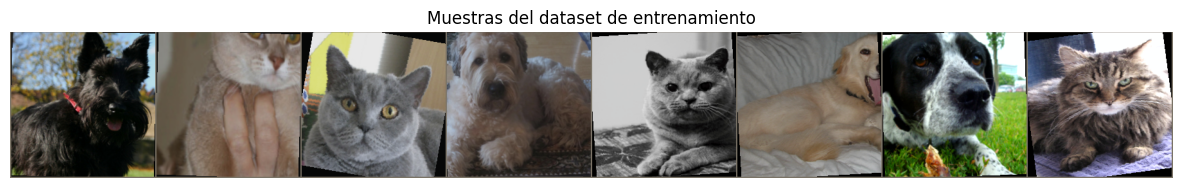

In [37]:
def imshow(inp, title=None):
    """Mostrar imagen desde tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    # Desnormalizar
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')

# Obtener un batch de entrenamiento
inputs, classes = next(iter(train_loader))

# Crear grid de imágenes
out = torchvision.utils.make_grid(inputs[:8])

plt.figure(figsize=(15, 5))
imshow(out, title='Muestras del dataset de entrenamiento')
plt.show()

## 8. Cargar ResNet18 preentrenado y modificar la última capa

### Estrategia de Transfer Learning:
1. Cargar ResNet18 con pesos de ImageNet
2. **Congelar todas las capas** (requiere_grad = False)
3. **Reemplazar la última capa FC** para 37 clases
4. Solo entrenar la última capa

In [38]:
# Cargar ResNet18 preentrenado
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

print("Modelo ResNet18 cargado con pesos de ImageNet")
print(f"\nArquitectura original de la última capa:")
print(model.fc)

Modelo ResNet18 cargado con pesos de ImageNet

Arquitectura original de la última capa:
Linear(in_features=512, out_features=1000, bias=True)


In [39]:
# PASO CLAVE: Congelar todas las capas del modelo
print("\n=== CONGELANDO CAPAS ===")
for param in model.parameters():
    param.requires_grad = False

print("✓ Todas las capas congeladas (requires_grad = False)")

# Verificar que las capas estén congeladas
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"  Parámetros congelados: {frozen_params:,}")


=== CONGELANDO CAPAS ===
✓ Todas las capas congeladas (requires_grad = False)
  Parámetros congelados: 11,689,512


In [41]:
# Reemplazar la última capa (fully connected) para 37 clases
num_classes = 37
num_ftrs = model.fc.in_features  # 512 features de entrada para ResNet18

# Nueva capa FC con inicialización
model.fc = nn.Linear(num_ftrs, num_classes)

print(f"\n=== NUEVA CAPA FINAL ===")
print(f"Nueva capa FC: {num_ftrs} -> {num_classes}")
print(model.fc)

# Mover modelo al dispositivo
model = model.to(device)

# Verificar parámetros entrenables
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"\n=== RESUMEN DE PARÁMETROS ===")
print(f"Total de parámetros: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")
print(f"Parámetros congelados: {total_params - trainable_params:,}")
print(f"Porcentaje entrenable: {100 * trainable_params / total_params:.2f}%")


=== NUEVA CAPA FINAL ===
Nueva capa FC: 512 -> 37
Linear(in_features=512, out_features=37, bias=True)

=== RESUMEN DE PARÁMETROS ===
Total de parámetros: 11,195,493
Parámetros entrenables: 18,981
Parámetros congelados: 11,176,512
Porcentaje entrenable: 0.17%


## 9. Configurar función de pérdida y optimizador

Solo optimizamos los parámetros de la última capa.

In [42]:
# Función de pérdida
criterion = nn.CrossEntropyLoss()

# Optimizador - SOLO optimiza los parámetros entrenables (última capa)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), 
                      lr=0.001)

# Learning rate scheduler (opcional)
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print("Configuración:")
print(f"  Función de pérdida: CrossEntropyLoss")
print(f"  Optimizador: Adam (lr=0.001)")
print(f"  Scheduler: StepLR (step=7, gamma=0.1)")
print(f"  Parámetros a optimizar: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Configuración:
  Función de pérdida: CrossEntropyLoss
  Optimizador: Adam (lr=0.001)
  Scheduler: StepLR (step=7, gamma=0.1)
  Parámetros a optimizar: 18,981


## 10. Función de entrenamiento

In [43]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    """
    Entrenar el modelo con transfer learning.
    
    Args:
        model: Modelo a entrenar
        criterion: Función de pérdida
        optimizer: Optimizador
        scheduler: Learning rate scheduler
        num_epochs: Número de épocas
    
    Returns:
        model: Mejor modelo entrenado
        history: Historial de entrenamiento
    """
    since = time.time()
    
    # Historial
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'\nÉpoca {epoch+1}/{num_epochs}')
        print('-' * 60)
        
        # Cada época tiene fase de entrenamiento y validación
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Modo entrenamiento
            else:
                model.eval()   # Modo evaluación
            
            running_loss = 0.0
            running_corrects = 0
            
            # Iterar sobre los datos
            pbar = tqdm(dataloaders[phase], desc=f'{phase.capitalize()}')
            for inputs, labels in pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Zero gradients
                optimizer.zero_grad()
                
                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    # Backward + optimize solo en entrenamiento
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                # Estadísticas
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                # Actualizar barra de progreso
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})
            
            if phase == 'train':
                scheduler.step()
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            # Guardar en historial
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
            
            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Guardar mejor modelo
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f'✓ Mejor modelo actualizado (acc: {best_acc:.4f})')
    
    time_elapsed = time.time() - since
    print(f'\n{"="*60}')
    print(f'Entrenamiento completado en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Mejor accuracy de validación: {best_acc:.4f}')
    
    # Cargar mejores pesos
    model.load_state_dict(best_model_wts)
    return model, history

## 11. Entrenar el modelo

In [ ]:
# Entrenar el modelo
num_epochs = 5

print("Iniciando entrenamiento...")
print(f"Épocas: {num_epochs}")
print(f"\nRECORDAR: Solo se entrena la última capa (FC)")
print(f"Todas las demás capas están congeladas\n")

model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=num_epochs)

Iniciando entrenamiento...
Épocas: 5

RECORDAR: Solo se entrena la última capa (FC)
Todas las demás capas están congeladas


Época 1/5
------------------------------------------------------------


Train: 100%|██████████| 184/184 [01:31<00:00,  2.01it/s, loss=1.8133]


Train Loss: 2.0674 Acc: 0.4916


Val: 100%|██████████| 46/46 [00:23<00:00,  1.99it/s, loss=1.2498]


Val Loss: 1.2001 Acc: 0.7109
✓ Mejor modelo actualizado (acc: 0.7109)

Época 2/5
------------------------------------------------------------


Train: 100%|██████████| 184/184 [01:37<00:00,  1.88it/s, loss=1.1010]


Train Loss: 1.1344 Acc: 0.6993


Val: 100%|██████████| 46/46 [00:28<00:00,  1.64it/s, loss=0.5479]


Val Loss: 0.9017 Acc: 0.7571
✓ Mejor modelo actualizado (acc: 0.7571)

Época 3/5
------------------------------------------------------------


Train:  80%|████████  | 148/184 [01:22<00:16,  2.20it/s, loss=0.5742]

## 12. Visualizar resultados del entrenamiento

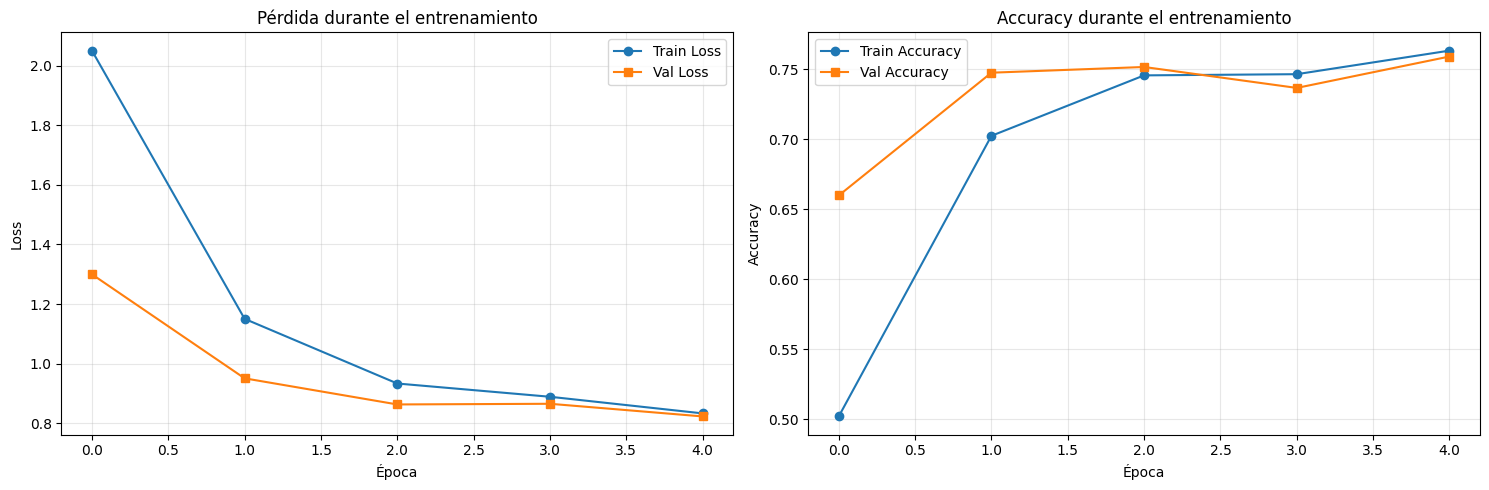


RESULTADOS FINALES:
Última Train Loss: 0.8331
Última Train Acc: 0.7634
Última Val Loss: 0.8229
Última Val Acc: 0.7592

Mejor Val Acc: 0.7592


In [14]:
# Graficar pérdida y accuracy
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pérdida
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Pérdida durante el entrenamiento')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='s')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy durante el entrenamiento')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Imprimir mejores resultados
print(f"\n{'='*60}")
print("RESULTADOS FINALES:")
print(f"{'='*60}")
print(f"Última Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Última Train Acc: {history['train_acc'][-1]:.4f}")
print(f"Última Val Loss: {history['val_loss'][-1]:.4f}")
print(f"Última Val Acc: {history['val_acc'][-1]:.4f}")
print(f"\nMejor Val Acc: {max(history['val_acc']):.4f}")

## 13. Guardar el modelo entrenado

In [15]:
# Guardar el modelo
model_save_path = '../models/resnet18_transfer_learning_oxford.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'num_classes': num_classes,
    'class_names': full_dataset.class_names
}, model_save_path)

print(f"Modelo guardado en: {model_save_path}")

Modelo guardado en: ../models/resnet18_transfer_learning_oxford.pth


## 14. Evaluar el modelo - Predicciones en validación

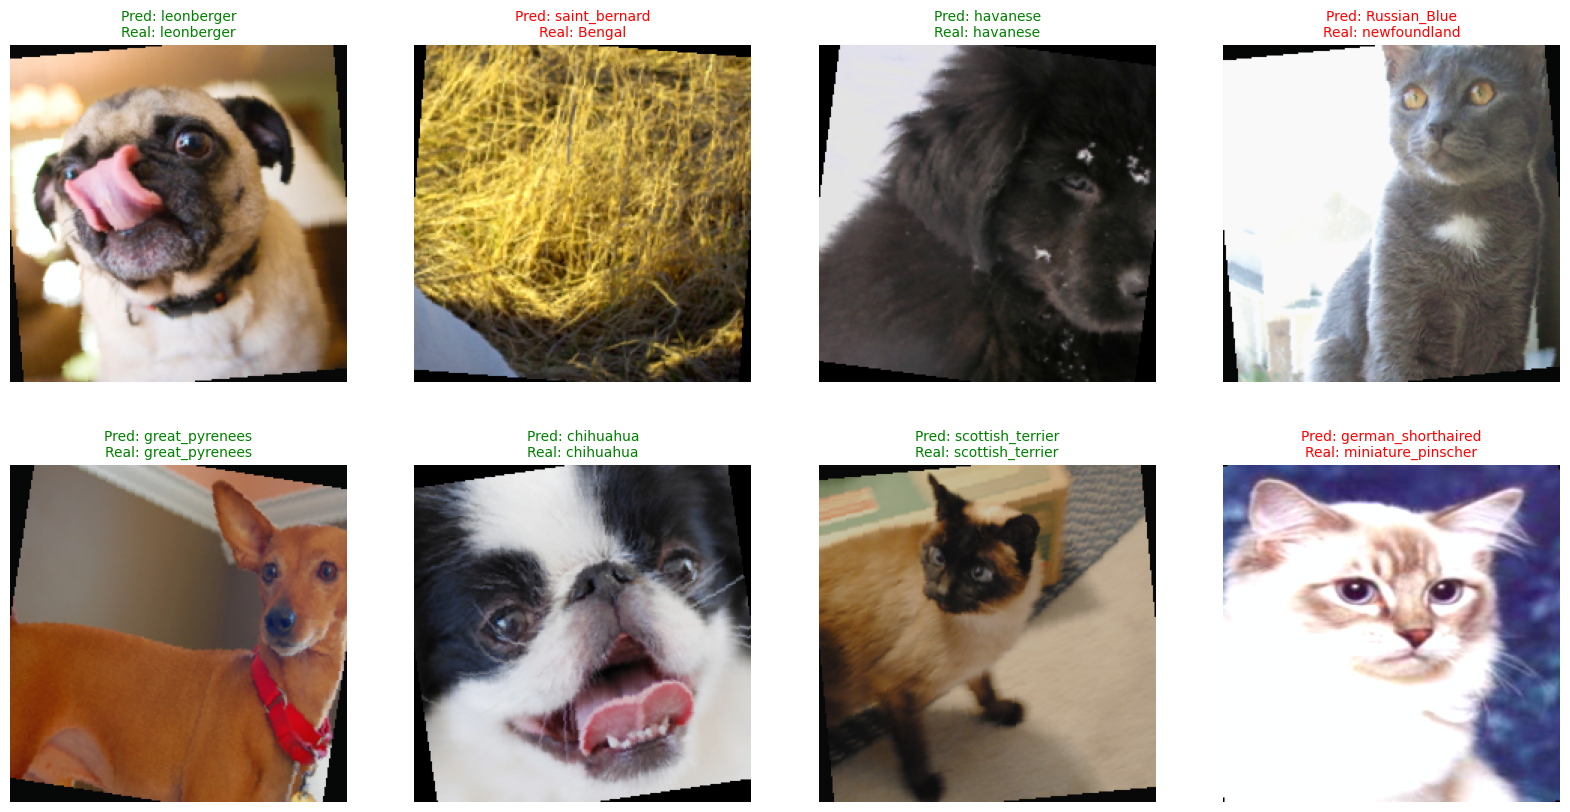

In [20]:
def visualize_predictions(model, dataloader, class_names, num_images=8):
    """Visualizar predicciones del modelo."""
    model.eval()
    
    images_shown = 0
    fig = plt.figure(figsize=(20, 10))
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for i in range(inputs.size(0)):
                if images_shown >= num_images:
                    return
                
                images_shown += 1
                ax = fig.add_subplot(2, num_images//2, images_shown)
                
                # Desnormalizar imagen
                img = inputs[i].cpu().numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)
                
                ax.imshow(img)
                ax.axis('off')
                
                pred_class = class_names[preds[i]]
                true_class = class_names[labels[i]]
                
                color = 'green' if preds[i] == labels[i] else 'red'
                ax.set_title(f'Pred: {pred_class}\nReal: {true_class}', 
                           color=color, fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Visualizar predicciones
visualize_predictions(model, val_loader, full_dataset.class_names, num_images=8)

## 15. Análisis adicional - Matriz de confusión

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, dataloader):
    """Evaluar modelo y obtener predicciones completas."""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Evaluando'):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds)

# Obtener predicciones
y_true, y_pred = evaluate_model(model, val_loader)

# Reporte de clasificación
print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN")
print("="*60)
print(classification_report(y_true, y_pred, 
                          target_names=full_dataset.class_names,
                          zero_division=0))

Evaluando: 100%|██████████| 46/46 [00:25<00:00,  1.82it/s]


REPORTE DE CLASIFICACIÓN
                            precision    recall  f1-score   support

                Abyssinian       0.85      0.72      0.78        40
                    Bengal       0.43      0.72      0.54        32
                    Birman       0.86      0.50      0.63        36
                    Bombay       0.87      0.66      0.75        41
         British_Shorthair       0.86      0.56      0.68        45
              Egyptian_Mau       0.77      0.73      0.75        33
                Maine_Coon       0.59      0.74      0.66        35
                   Persian       0.60      0.75      0.67        28
                   Ragdoll       0.50      0.74      0.60        38
              Russian_Blue       0.56      0.91      0.70        35
                   Siamese       0.48      0.71      0.57        38
                    Sphynx       0.78      0.88      0.82        48
          american_bulldog       0.91      0.74      0.82        43
 american_pit_bull_te

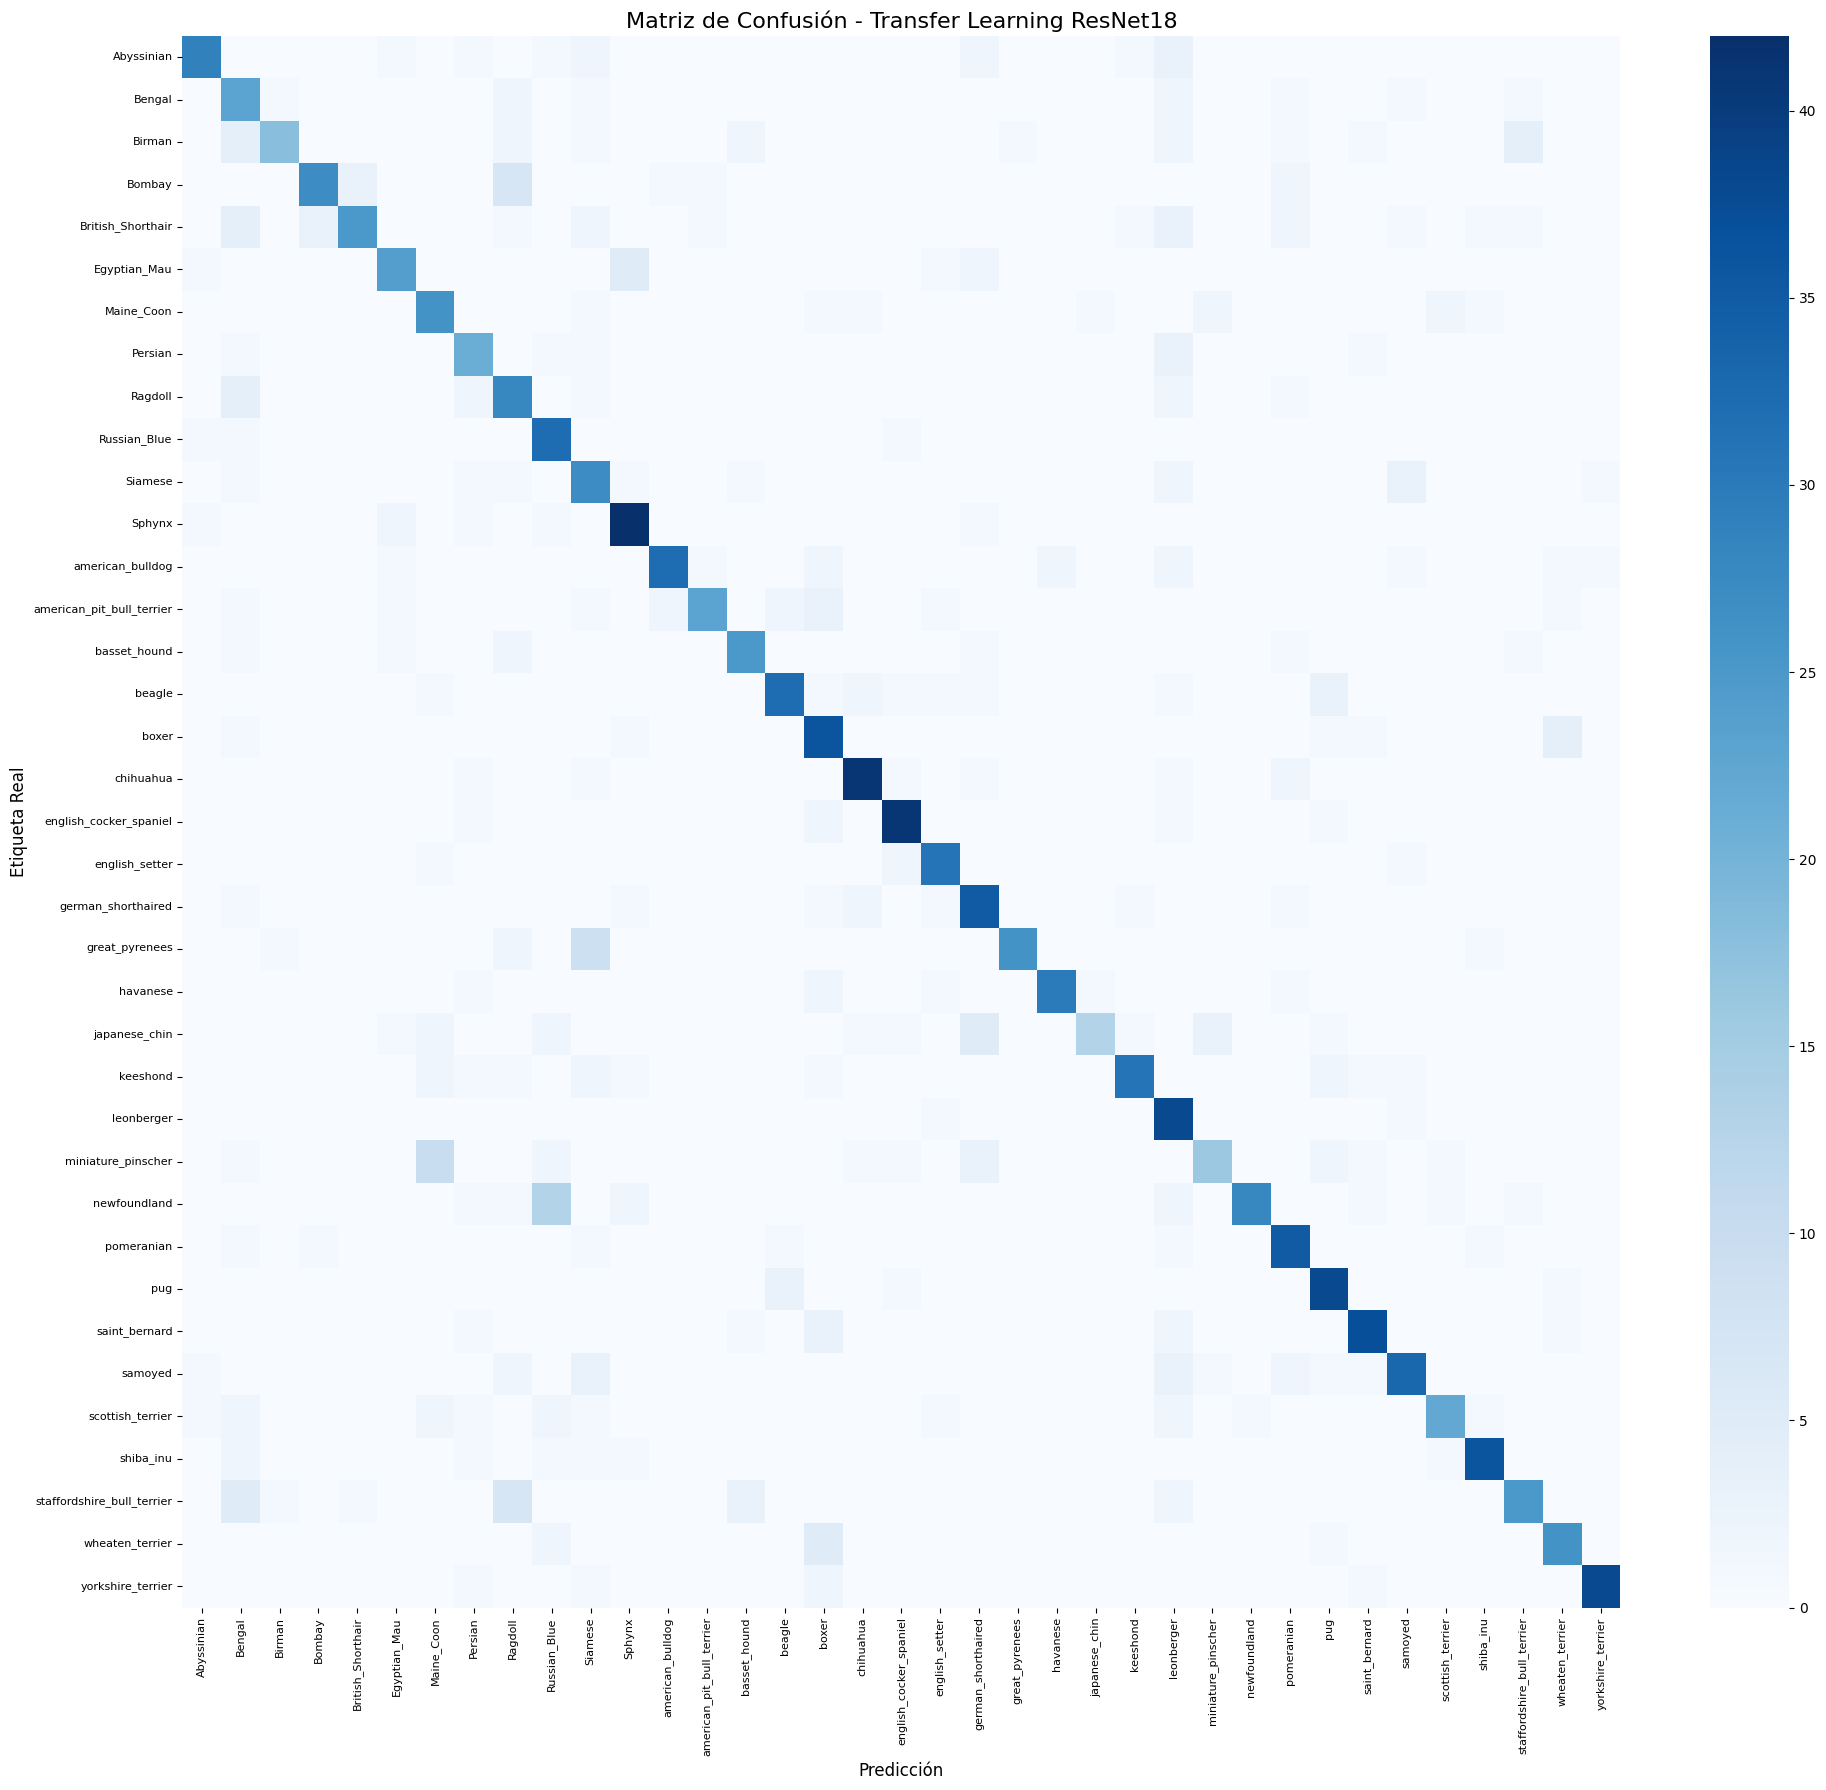


Accuracy por clase:
Abyssinian          : 0.7250
Bengal              : 0.7188
Birman              : 0.5000
Bombay              : 0.6585
British_Shorthair   : 0.5556
Egyptian_Mau        : 0.7273
Maine_Coon          : 0.7429
Persian             : 0.7500
Ragdoll             : 0.7368
Russian_Blue        : 0.9143
Siamese             : 0.7105
Sphynx              : 0.8750
american_bulldog    : 0.7442
american_pit_bull_terrier: 0.6571
basset_hound        : 0.7812
beagle              : 0.7442
boxer               : 0.8182
chihuahua           : 0.8542
english_cocker_spaniel: 0.8913
english_setter      : 0.8857
german_shorthaired  : 0.8140
great_pyrenees      : 0.6667
havanese            : 0.8333
japanese_chin       : 0.4333
keeshond            : 0.7209
leonberger          : 0.9500
miniature_pinscher  : 0.4211
newfoundland        : 0.5600
pomeranian          : 0.8537
pug                 : 0.8837
saint_bernard       : 0.8222
samoyed             : 0.7021
scottish_terrier    : 0.6111
shiba_inu      

In [18]:
# Matriz de confusión (simplificada para 37 clases)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
            xticklabels=full_dataset.class_names,
            yticklabels=full_dataset.class_names)
plt.title('Matriz de Confusión - Transfer Learning ResNet18', fontsize=16)
plt.ylabel('Etiqueta Real', fontsize=12)
plt.xlabel('Predicción', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Accuracy por clase
class_accuracy = cm.diagonal() / cm.sum(axis=1)
print("\nAccuracy por clase:")
for i, acc in enumerate(class_accuracy):
    if not np.isnan(acc):
        print(f"{full_dataset.class_names[i]:20s}: {acc:.4f}")